In [11]:
#import relevant libraries
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import NLCLIMB_asyn
import NLMATH_asyn

#NOTE: SUPPRESSES WARNINGS!

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

In [12]:
#initial file processing

laptop = "C:\\Users\\lnico\\"
homecomp = "C:\\Users\\user\\"
labcomp = "C:\\Users\\User\\"

path2 = "NUS Dropbox\\acclab\\Nicole M Lee\\"
openPath = homecomp + path2 + "PD\\Data Compilation\\"
savefiglocation = openPath + "images\\"

isExist = os.path.exists(savefiglocation)
if not isExist:
    os.makedirs(savefiglocation)

expt = "elav x 51376_D30"

listofgenotypes = sorted(f[:-4] for f in os.listdir(openPath) if f.endswith(".csv"))

phase = ["First phase", "Second phase", "Third phase"]

#the experimental is always light blue, the first control black, the second brown
lightblue = "#4DA6FF"
brown = "#8B4513"
colors = [lightblue, "#000000", brown]

cross, age = expt.rsplit("_", 1)
driver, responder = cross.split(" x ", 1)

wts = []
for side, parent in zip(["driver", "responder"], [driver, responder]):
    control = "w1118 x " + parent + "_" + age
    if control in listofgenotypes:
        wts.append(control)
    else:
        print("the " + side + " control " + control + " does not exist, plotting without it")

if len(wts) == 0:
    raise Exception("neither parental control of " + expt + " exists, nothing to plot against")

genotypes = [expt] + wts
colors = colors[:len(genotypes)]

dfs = []
for n in genotypes:
    df = pd.read_csv(openPath + n + ".csv")
    df = df.drop(df.columns[[0]], axis = 1)   #the compiled CSVs carry an index column
    dfs.append(NLCLIMB_asyn.generation(df, n))

nnumbers = [int(0.20*(len(df.columns)-2)) for df in dfs]
labels = [n + " (n=" + str(nn) + ")" for n, nn in zip(genotypes, nnumbers)]

for n, nn in zip(genotypes, nnumbers):
    print(n, "n =", nn)

the responder control w1118 x 51376_D30 does not exist, plotting without it
elav x 51376_D30 n = 27
w1118 x elav_D30 n = 21


In [13]:
#TOTAL calculations for graphs
#one entry per genotype: every fly, and the mean with its 95% CI

ally = []
meany = []
allv = []
meanv = []

for df in dfs:
    df_y = NLMATH_asyn.calcgraph(df, "Y.*")
    df_v = NLMATH_asyn.calcgraph(df, "Velocity.*")

    ally.append(df_y)
    meany.append(NLMATH_asyn.meangraph(df_y))
    allv.append(df_v)
    meanv.append(NLMATH_asyn.meangraph(df_v))

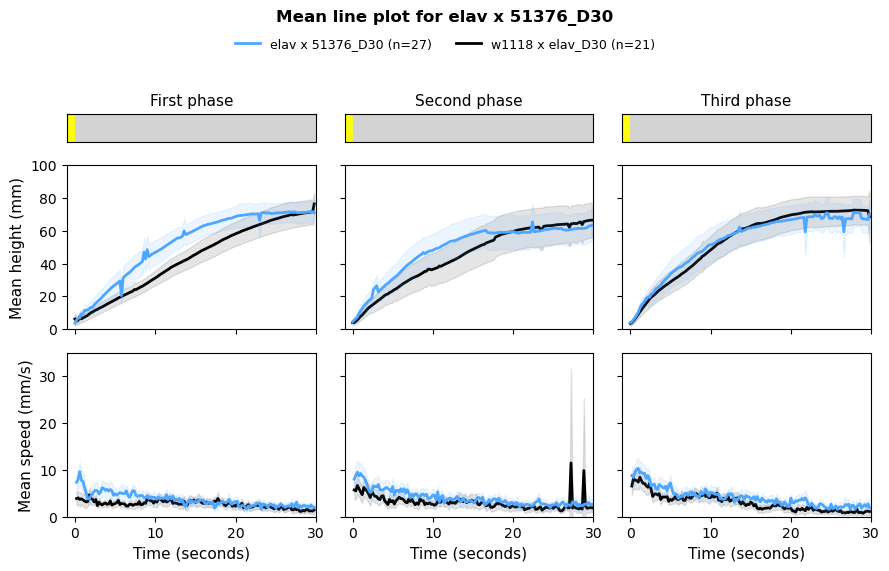

In [14]:
#mean line plot

mpl.rcParams['svg.fonttype'] = 'none'

figmean, axs = plt.subplots(3, 3, figsize=(9, 5.5), sharex = "col", sharey = "row",
                            gridspec_kw={'height_ratios': [1, 6, 6]})

#cartoon
for col, n in enumerate(phase):
    axs[0, col].axvspan(-1, 0, color = "#FFFF00", label = "_nolegend_")    #the tap
    axs[0, col].axvspan(0, 30, color = "lightgray", label = "_nolegend_")  #the climb
    axs[0, col].get_yaxis().set_visible(False)
    axs[0, col].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axs[0, col].set_title(n, fontsize = 11)

for col, n in enumerate(phase):

    #the experimental is first in the list and sits on top of the controls
    for i, (dfy, dfv, label, color) in enumerate(zip(meany, meanv, labels, colors)):
        zo = len(genotypes) - i

        #y pos
        dfy = dfy[dfy.ExperimentState == n]
        axs[1, col].plot(dfy["Seconds"], dfy["mean"], color = color, linewidth = 2,
                         label = label if col == 0 else "_nolegend_", zorder = zo)
        axs[1, col].fill_between(dfy["Seconds"], dfy["mean"] - dfy["CI"], dfy["mean"] + dfy["CI"],
                                 color = color, alpha = .1, label = "_nolegend_", zorder = zo)

        #speed
        dfv = dfv[dfv.ExperimentState == n]
        axs[2, col].plot(dfv["Seconds"], dfv["mean"], color = color, linewidth = 2,
                         label = "_nolegend_", zorder = zo)
        axs[2, col].fill_between(dfv["Seconds"], dfv["mean"] - dfv["CI"], dfv["mean"] + dfv["CI"],
                                 color = color, alpha = .1, label = "_nolegend_", zorder = zo)

    axs[1, col].set_ylim([0, 100])
    axs[2, col].set_ylim([0, 35])
    axs[2, col].set_xlabel("Time (seconds)", fontsize = 11)

axs[1, 0].set_ylabel("Mean height (mm)", fontsize = 11)
axs[2, 0].set_ylabel("Mean speed (mm/s)", fontsize = 11)

#Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
    ax.set_xlim([-1, 30])

figmean.suptitle("Mean line plot for " + expt, fontweight = 'bold', fontsize = 12, y = 1.03)
figmean.legend(frameon = False, fontsize = 9, ncol = len(labels), loc = "upper center",
               bbox_to_anchor = (0.5, 1.0))
figmean.tight_layout(rect=[0, 0, 1, 0.96])

#figmean.savefig(savefiglocation + "Mean line plot for " + expt + ".svg", bbox_inches='tight')


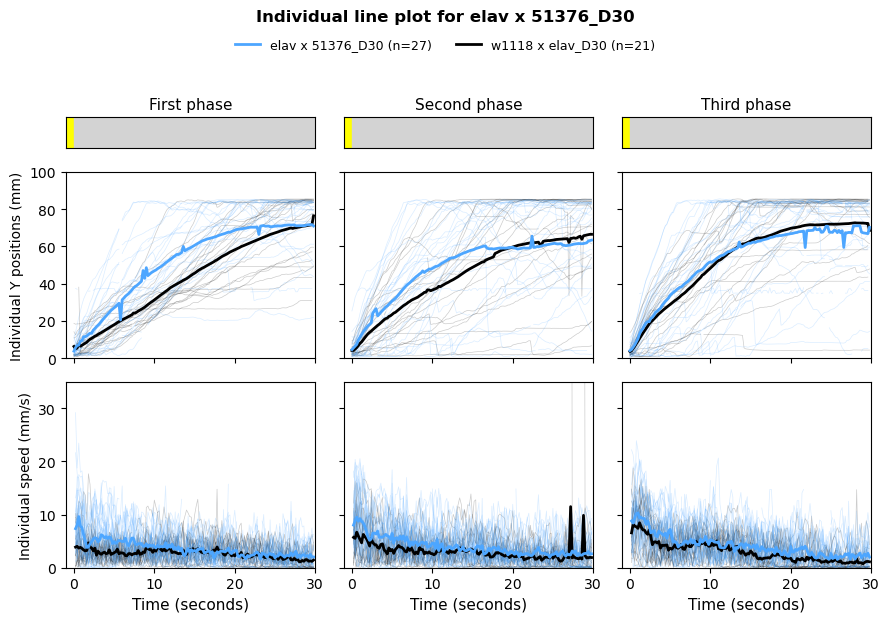

In [15]:
#individual line plot

mpl.rcParams['svg.fonttype'] = 'none'

figindiv, axs = plt.subplots(3, 3, figsize=(9, 6), sharex = "col", sharey = "row",
                             gridspec_kw={'height_ratios': [1, 6, 6]})

#cartoon
for col, n in enumerate(phase):
    axs[0, col].axvspan(-1, 0, color = "#FFFF00", label = "_nolegend_")    #the tap
    axs[0, col].axvspan(0, 30, color = "lightgray", label = "_nolegend_")  #the climb
    axs[0, col].get_yaxis().set_visible(False)
    axs[0, col].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axs[0, col].set_title(n, fontsize = 11)

for col, n in enumerate(phase):

    #the experimental is first in the list and sits on top of the controls
    for i, (dfay, dfav, dfy, dfv, label, color) in enumerate(zip(ally, allv, meany, meanv, labels, colors)):
        zo = len(genotypes) - i

        #y pos, every fly then the mean
        dfay = dfay[dfay.ExperimentState == n]
        axs[1, col].plot(dfay["Seconds"], dfay.iloc[:, 2:], color = color, alpha = 0.2,
                         linewidth = 0.5, label = "_nolegend_", zorder = zo)

        dfy = dfy[dfy.ExperimentState == n]
        axs[1, col].plot(dfy["Seconds"], dfy["mean"], color = color, linewidth = 2,
                         label = label if col == 0 else "_nolegend_", zorder = zo + len(genotypes))

        #speed, every fly then the mean
        dfav = dfav[dfav.ExperimentState == n]
        axs[2, col].plot(dfav["Seconds"], dfav.iloc[:, 2:], color = color, alpha = 0.2,
                         linewidth = 0.5, label = "_nolegend_", zorder = zo)

        dfv = dfv[dfv.ExperimentState == n]
        axs[2, col].plot(dfv["Seconds"], dfv["mean"], color = color, linewidth = 2,
                         label = "_nolegend_", zorder = zo + len(genotypes))

    axs[1, col].set_ylim([0, 100])
    axs[2, col].set_ylim([0, 35])
    axs[2, col].set_xlabel("Time (seconds)", fontsize = 11)

axs[1, 0].set_ylabel("Individual Y positions (mm)", fontsize = 10)
axs[2, 0].set_ylabel("Individual speed (mm/s)", fontsize = 10)

#Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
    ax.set_xlim([-1, 30])

figindiv.suptitle("Individual line plot for " + expt, fontweight = 'bold', fontsize = 12, y = 1.03)
figindiv.legend(frameon = False, fontsize = 9, ncol = len(labels), loc = "upper center",
                bbox_to_anchor = (0.5, 1.0))
figindiv.tight_layout(rect=[0, 0, 1, 0.96])

#figindiv.savefig(savefiglocation + "Individual line plot for " + expt + ".svg", bbox_inches='tight')
